1. wear the required personal protective equipment(PPE) fo the job.
2. observe and follow appropriate occupational health and safety(OHS) requirments during the demonstration.
3. check electricity. peripherals device and Internet connections to your computer.
4. start computer.
5. check for software errors and troubleshoot problems.
6. collect the resources(dataset) and materials from your assessor as per the job requirments.
7. create weather prediction system.
8. Set up the python environment requires to creat the system.
9. Load the weather dataset in tho environment.
10. perform initial data inspection.
11. Define the ML problem statement.
12. pform feature selection.
13. split the dataset for training and testing.
14. Implement a baseline ML model.
15. Apply feature scaling, compare model performance before and after scaling.
16. train other optimized ML models(at least 2 model).
17. Evaluate model performance.
18. Visualize model performance.
19. Detect Overfitting and underfitting.
20. save and deploy the finaal model.
21. Submit the final output to the competency assessor.
22. shut down the computer and clean your workplace.
23. clean tools, equipment, materials, and work area.....

In [ ]:
!python --version

Python 3.12.13


In [ ]:
# importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Job_2_resource_Weather Test Data.csv')

In [ ]:
df.tail()

,row ID,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
42672,Row43633,Uluru,2.4,19.1,0.0,NaN,NaN,E,33.0,SE,...,17.0,59.0,24.0,1030.0,1026.2,NaN,NaN,8.0,18.8,No
42673,Row43634,Uluru,2.3,21.4,0.0,NaN,NaN,SE,22.0,SE,...,7.0,60.0,28.0,1026.9,1022.8,NaN,NaN,8.9,20.3,No
42674,Row43635,Uluru,2.6,22.5,0.0,NaN,NaN,S,19.0,S,...,7.0,59.0,24.0,1025.0,1021.4,NaN,NaN,8.8,22.1,No
42675,Row43636,Uluru,7.4,20.6,0.0,NaN,NaN,E,35.0,ESE,...,17.0,63.0,33.0,1027.2,1023.3,NaN,NaN,11.0,20.3,No
42676,Row43637,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,7.0,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No


In [ ]:
df.shape

(42677, 22)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42677 entries, 0 to 42676
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row ID         42677 non-null  object 
 1   Location       42677 non-null  object 
 2   MinTemp        42483 non-null  float64
 3   MaxTemp        42585 non-null  float64
 4   Rainfall       42250 non-null  float64
 5   Evaporation    24365 non-null  float64
 6   Sunshine       22178 non-null  float64
 7   WindGustDir    39868 non-null  object 
 8   WindGustSpeed  39887 non-null  float64
 9   WindDir9am     39670 non-null  object 
 10  WindDir3pm     41547 non-null  object 
 11  WindSpeed9am   42264 non-null  float64
 12  WindSpeed3pm   41882 non-null  float64
 13  Humidity9am    42136 non-null  float64
 14  Humidity3pm    41573 non-null  float64
 15  Pressure9am    38411 non-null  float64
 16  Pressure3pm    38432 non-null  float64
 17  Cloud9am       26592 non-null  float64
 18  Cloud3

In [ ]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,42483.000000,42585.000000,42250.000000,24365.000000,22178.000000,39887.000000,42264.000000,41882.000000,42136.000000,41573.000000,38411.000000,38432.000000,26592.000000,25585.000000,42387.000000,41855.000000
mean,12.210032,23.246068,2.342862,5.489715,7.647831,40.001379,13.995315,18.607516,68.791176,51.597672,1017.581591,1015.192792,4.412041,4.466054,17.028266,21.700982
std,6.432122,7.123596,8.412106,4.248850,3.778019,13.605915,8.872445,8.806916,18.996115,20.844525,7.094070,7.016408,2.887927,2.729640,6.501771,6.951426
min,-8.200000,-4.800000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,1.000000,1.000000,982.200000,977.100000,0.000000,0.000000,-7.200000,-5.400000
25%,7.600000,18.000000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.800000,21.100000
75%,16.900000,28.300000,0.600000,7.400000,10.700000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.500000
max,31.800000,47.000000,278.400000,145.000000,14.300000,122.000000,74.000000,83.000000,100.000000,100.000000,1040.400000,1038.900000,8.000000,8.000000,39.400000,45.400000


In [ ]:
df.isnull().sum()

,0
row ID,0
Location,0
MinTemp,194
MaxTemp,92
Rainfall,427
Evaporation,18312
Sunshine,20499
WindGustDir,2809
WindGustSpeed,2790
WindDir9am,3007


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

(16846, 22)

In [ ]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,16846.000000,16846.000000,16846.000000,16846.000000,16846.000000,16846.000000,16846.000000,16846.000000,16846.000000,16846.000000,16846.00000,16846.000000,16846.000000,16846.000000,16846.000000,16846.000000
mean,13.472652,24.236169,2.053485,5.522237,7.764555,40.845067,15.614864,19.768966,65.882346,49.687582,1017.17730,1014.735154,4.208002,4.285884,18.223762,22.722646
std,6.481411,6.981875,6.990011,3.692763,3.759481,13.379706,8.292799,8.460839,18.419450,20.224100,6.86216,6.815424,2.794741,2.654221,6.611865,6.853896
min,-5.200000,4.100000,0.000000,0.000000,0.000000,9.000000,2.000000,2.000000,1.000000,1.000000,982.20000,977.100000,0.000000,0.000000,-0.700000,3.700000
25%,8.500000,18.700000,0.000000,2.800000,5.100000,31.000000,9.000000,13.000000,55.000000,35.000000,1012.60000,1010.100000,1.000000,2.000000,13.000000,17.300000
50%,13.200000,24.000000,0.000000,5.000000,8.700000,39.000000,15.000000,19.000000,67.000000,51.000000,1017.10000,1014.600000,5.000000,5.000000,17.900000,22.500000
75%,18.500000,29.700000,0.600000,7.500000,10.700000,48.000000,20.000000,26.000000,79.000000,63.000000,1021.80000,1019.300000,7.000000,7.000000,23.300000,27.900000
max,29.700000,46.400000,206.200000,72.200000,14.300000,122.000000,67.000000,61.000000,100.000000,100.000000,1040.40000,1038.900000,8.000000,8.000000,39.400000,45.400000


In [ ]:
df.select_dtypes(include='object').columns

Index(['row ID', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday'],
      dtype='object')

In [ ]:
df.drop('row ID',axis=1,inplace=True)

In [ ]:
df.select_dtypes(include='object').columns

Index(['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday'], dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
col_encode=['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

for i in col_encode:
  df[i]=le.fit_transform(df[i])

In [ ]:
df.dtypes

,0
Location,int64
MinTemp,float64
MaxTemp,float64
Rainfall,float64
Evaporation,float64
Sunshine,float64
WindGustDir,int64
WindGustSpeed,float64
WindDir9am,int64
WindDir3pm,int64


Define ML model statement type: Supervised learning .

task: Classification (based on target column)


In [ ]:
X=df.drop('RainToday', axis=1)

In [ ]:
X.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
1756,4,18.4,28.9,0.0,14.8,13.0,8,37.0,10,10,19.0,19.0,30.0,8.0,1012.9,1012.1,1.0,1.0,20.3,27.0
1757,4,19.4,37.6,0.0,10.8,10.6,5,46.0,5,6,30.0,15.0,42.0,22.0,1012.3,1009.2,1.0,6.0,28.7,34.9
1758,4,21.9,38.4,0.0,11.4,12.2,14,31.0,14,15,6.0,6.0,37.0,22.0,1012.7,1009.1,1.0,5.0,29.1,35.6
1759,4,24.2,41.0,0.0,11.2,8.4,14,35.0,7,14,17.0,13.0,19.0,15.0,1010.7,1007.4,1.0,6.0,33.6,37.6
1760,4,19.7,35.5,0.0,11.0,12.7,4,41.0,5,15,15.0,17.0,61.0,14.0,1007.9,1005.8,1.0,5.0,24.0,33.6


In [ ]:
y = df['RainToday']
y.head()

,RainToday
1756,0
1757,0
1758,0
1759,0
1760,0


In [ ]:
from sklearn.model_selection import train_test_split
#train test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

In [ ]:
X_train.shape, X_test.shape , y_train.shape, y_test.shape

((13476, 20), (3370, 20), (13476,), (3370,))

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model2 = DecisionTreeClassifier()
model2.fit(X_train,y_train)


DecisionTreeClassifier()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model3 = RandomForestClassifier()
model3.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
logistic = model.score(X_test,y_test)
print(logistic)

0.9875370919881306


In [ ]:
DecisionTree = model2.score(X_test,y_test)
print(DecisionTree)

1.0


In [ ]:
RandomForest = model3.score(X_test,y_test)
print(RandomForest)

1.0


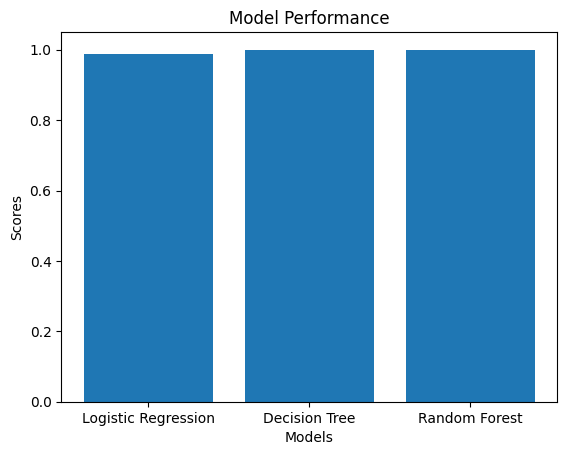

In [ ]:
models = ['Logistic Regression','Decision Tree','Random Forest']
scores = [logistic,DecisionTree,RandomForest]
plt.bar(models,scores)
plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Performance')
plt.show()

overfit or underfit check

In [ ]:
from sklearn.metrics import accuracy_score
# training accuracy
y_train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train,y_train_pred)
print('Training Accuracy: ',train_acc)

#testing accuracy
y_test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test,y_test_pred)
print('Testing Accuracy: ',test_acc)

Training Accuracy:  0.9890175126150192
Testing Accuracy:  0.9875370919881306


Train high + Test Low --> Overfitting

Train Low + Test High --> Underfitting

Train High + Test High --> Good fit

In [ ]:
if train_acc > 0.99 and test_acc < 0.70:
  print('Model is Overfit')
elif train_acc < 0.99 and test_acc < 0.70:
  print('Model is Underfit')
else:
  print('Model is Good')

Model is Good


model export in joblib

In [ ]:
import joblib
#saved the train model and scaler
joblib.dump(model,'weather_model.joblib')
joblib.dump(scaler,'scaler.joblib')

['scaler.joblib']

Model Development the end .

next we move to vscode for deployment ..